# Aula 03 Hands-On — CNNs e o Viés Indutivo Espacial: Quando Ele Paga e Quando Não Paga

## Contexto
Agora que o MLP já mostrou utilidade em imagens pequenas, o próximo passo é testar se um viés indutivo desenhado para visão computacional melhora a eficiência estatística. A resposta honesta é: **depende dos dados**. Por isso este notebook roda o mesmo par de modelos — um baseline linear sobre pixels achatados e uma CNN pequena — em **três cenários**:

- **Cenário A — dígitos 8×8 (`load_digits`)**: imagens minúsculas, já centralizadas e normalizadas. A posição de cada traço é praticamente fixa.
- **Cenário B — formas sintéticas 28×28**: seis padrões locais (cruz, anel, canto em L, barras horizontais, barras verticais, xadrez) desenhados em **posições sorteadas** da imagem, com tamanho, espessura, contraste e ruído variáveis. A classe depende exclusivamente do **padrão espacial local**, não de onde ele está.
- **Controle — as mesmas formas, sempre centralizadas**: mesmo gerador, mesmo ruído, deslocamento zero. Serve para isolar a translação como a variável causal.

O cenário B é o teste que interessa: um modelo linear sobre pixels achatados precisa de um "molde" por classe e por posição, enquanto a convolução com pooling detecta o mesmo padrão em qualquer lugar da imagem com o mesmo conjunto de pesos. E o controle é o que impede a conclusão preguiçosa: se o baseline se recuperar lá, então o que o derruba no cenário B é a translação, não a dificuldade das formas.

## Objetivos de aprendizagem
- Comparar uma regressão logística com uma CNN pequena sob o mesmo particionamento de dados, em dois regimes diferentes.
- Medir ganho em acurácia, macro-F1 e custo paramétrico.
- Isolar **translação** como a variável que decide quem vence, usando um cenário de controle com as mesmas formas centralizadas.
- Visualizar mapas de ativação da primeira camada convolucional para entender o que a rede está detectando.

## Pergunta experimental e hipótese
**Pergunta:** o viés indutivo da convolução (localidade, compartilhamento de pesos e invariância a translação via pooling) melhora o desempenho em qualquer problema de imagem, ou só quando os dados realmente têm estrutura espacial deslocável?

**Hipótese:**
- No **cenário A**, o baseline linear deve ser competitivo e possivelmente vencer: os dígitos já vêm centralizados em 8×8, então "onde" o pixel está já é informativo, e a invariância a translação da CNN joga fora informação útil.
- No **cenário B**, o baseline linear deve degradar bastante, porque cada classe aparece em posições diferentes e não existe um molde fixo de pixels que a descreva.
- A **CNN deve vencer com folga no cenário B**, e com número de parâmetros comparável ou menor que o do baseline.
- No **cenário de controle** (mesmas formas, sempre centralizadas) o baseline linear deve se recuperar — o que prova que o problema do baseline é a translação, e não as formas em si.
- Os primeiros mapas de ativação devem destacar bordas e traços dos padrões, e não regiões específicas da imagem.

## Setup, imports e semente de reprodutibilidade
O notebook usa `sklearn` para o baseline e `PyTorch` para a CNN. Mantemos a semente fixa (e o cuDNN em modo determinístico) para que a comparação não dependa de uma inicialização particularmente favorável e para que duas execuções produzam os mesmos números.

In [1]:
import random
from copy import deepcopy

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.datasets import load_digits
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, log_loss, recall_score
from sklearn.model_selection import train_test_split
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
device = 'cuda' if torch.cuda.is_available() else 'cpu'
plt.style.use('seaborn-v0_8-whitegrid')
device

'cuda'

## Carregamento dos datasets e preparação das imagens
O **cenário A** continua sendo o `load_digits` do `scikit-learn`: 1.797 imagens 8×8 já centralizadas.

O **cenário B** é gerado aqui dentro com `numpy`, sem download externo. Cada amostra é um carimbo de 9×9 a 13×13 pixels colado em uma tela 28×28 numa **posição sorteada**. Três cuidados tornam o experimento honesto:

1. **Tinta equalizada** — cada carimbo é reescalado para somar sempre a mesma quantidade de intensidade. Assim nenhuma classe é identificável pela soma dos pixels, que é justamente o tipo de atalho que um modelo linear adoraria usar.
2. **Amplitude, tamanho e espessura aleatórios** — o mesmo padrão aparece com contrastes e escalas diferentes.
3. **Ruído gaussiano** em toda a tela, igual para todas as classes.

O **cenário de controle** usa exatamente o mesmo gerador com deslocamento zero: as formas ficam sempre no centro. É o experimento que isola a translação como causa.

cenario A (digitos)  : (1797, 8, 8) em 10 classes
cenario B (formas)   : (6600, 28, 28) em 6 classes, deslocamento +-3 px
controle (centradas) : (6600, 28, 28), deslocamento 0 px
tinta media por classe (cenario B): [105.8, 103.3, 105.7, 105.5, 105.5, 104.8]


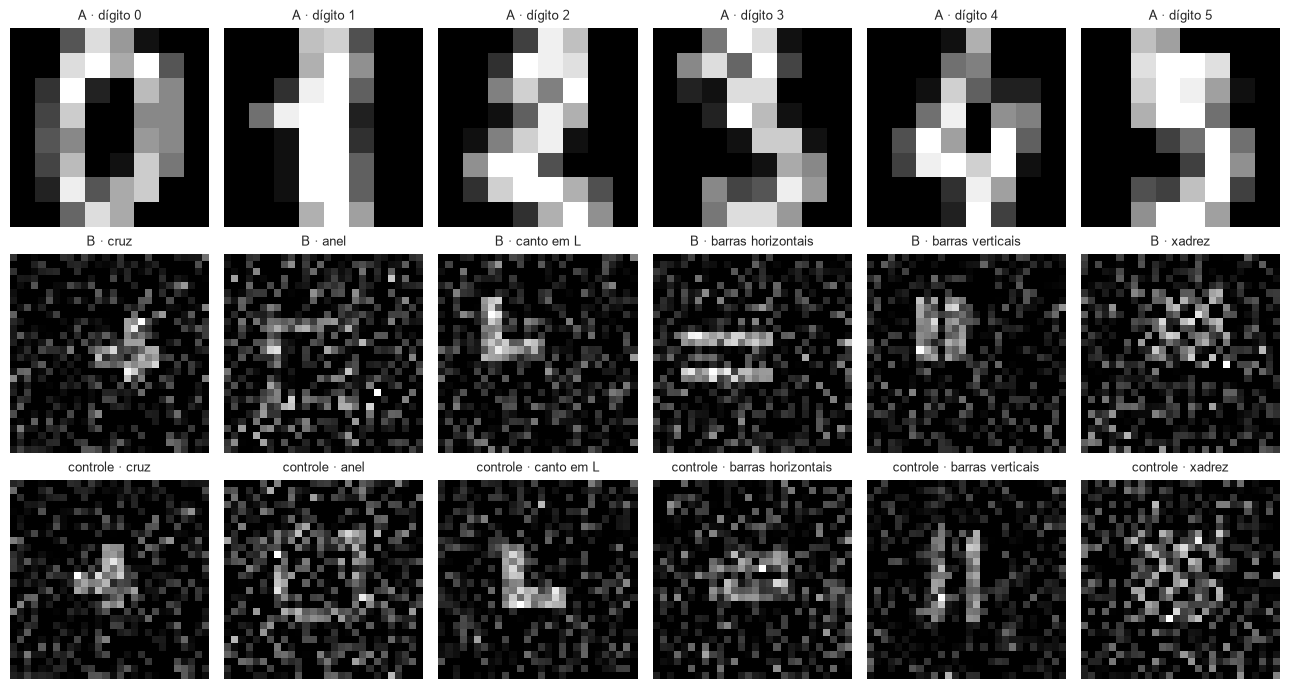

In [2]:
IMG_SIZE = 28
INK_BUDGET = 42.0
SHAPE_NAMES = ['cruz', 'anel', 'canto em L', 'barras horizontais', 'barras verticais', 'xadrez']
MAX_SHIFT = 3
PIXEL_NOISE = 0.25
N_PER_CLASS = 1100


def draw_stamp(kind, size, thickness, rng):
    """Desenha o padrao local e normaliza a 'tinta' total para INK_BUDGET."""
    stamp = np.zeros((size, size), dtype=np.float32)
    center = size // 2
    if kind == 0:                                   # cruz
        stamp[center:center + thickness, :] = 1
        stamp[:, center:center + thickness] = 1
    elif kind == 1:                                 # anel
        stamp[:thickness, :] = 1
        stamp[-thickness:, :] = 1
        stamp[:, :thickness] = 1
        stamp[:, -thickness:] = 1
    elif kind == 2:                                 # canto em L
        stamp[:, :thickness] = 1
        stamp[-thickness:, :] = 1
    elif kind == 3:                                 # barras horizontais
        a, b = size // 5, 3 * size // 5
        stamp[a:a + thickness, :] = 1
        stamp[b:b + thickness, :] = 1
    elif kind == 4:                                 # barras verticais
        a, b = size // 5, 3 * size // 5
        stamp[:, a:a + thickness] = 1
        stamp[:, b:b + thickness] = 1
    else:                                           # xadrez
        block = int(rng.choice([2, 3]))
        for i in range(size):
            for j in range(size):
                if ((i // block) + (j // block)) % 2 == 0:
                    stamp[i, j] = 1
    total = stamp.sum()
    return stamp * (INK_BUDGET / total) if total > 0 else stamp


def make_shape_dataset(n_per_class=N_PER_CLASS, noise=PIXEL_NOISE, max_shift=MAX_SHIFT, seed=SEED):
    rng = np.random.default_rng(seed)
    images, labels = [], []
    for kind in range(len(SHAPE_NAMES)):
        for _ in range(n_per_class):
            size = int(rng.choice([9, 11, 13]))
            thickness = int(rng.choice([2, 3]))
            stamp = draw_stamp(kind, size, thickness, rng) * rng.uniform(0.55, 1.0)
            canvas = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.float32)
            center = (IMG_SIZE - size) // 2
            low = max(0, center - max_shift)
            high = min(IMG_SIZE - size, center + max_shift)
            row = int(rng.integers(low, high + 1))
            col = int(rng.integers(low, high + 1))
            canvas[row:row + size, col:col + size] += stamp
            canvas += rng.normal(0, noise, size=(IMG_SIZE, IMG_SIZE)).astype(np.float32)
            images.append(np.clip(canvas, 0, 1.5))
            labels.append(kind)
    return np.stack(images), np.array(labels, dtype=np.int64)


digits = load_digits()
digits_images = digits.images.astype(np.float32) / 16.0
digits_flat = digits.data.astype(np.float32) / 16.0
digits_target = digits.target.astype(np.int64)

shapes_images, shapes_target = make_shape_dataset()
shapes_flat = shapes_images.reshape(len(shapes_images), -1)

centered_images, centered_target = make_shape_dataset(max_shift=0)
centered_flat = centered_images.reshape(len(centered_images), -1)

print(f'cenario A (digitos)  : {digits_images.shape} em {len(np.unique(digits_target))} classes')
print(f'cenario B (formas)   : {shapes_images.shape} em {len(SHAPE_NAMES)} classes, deslocamento +-{MAX_SHIFT} px')
print(f'controle (centradas) : {centered_images.shape}, deslocamento 0 px')
print('tinta media por classe (cenario B):',
      [round(float(shapes_images[shapes_target == k].sum(axis=(1, 2)).mean()), 1) for k in range(len(SHAPE_NAMES))])


def split_scenario(flat, images, target):
    X_train, X_temp, I_train, I_temp, y_train, y_temp = train_test_split(
        flat, images, target, test_size=0.4, stratify=target, random_state=SEED)
    X_val, X_test, I_val, I_test, y_val, y_test = train_test_split(
        X_temp, I_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=SEED)
    return {'X_train': X_train, 'X_test': X_test, 'I_train': I_train, 'I_val': I_val, 'I_test': I_test,
            'y_train': y_train, 'y_val': y_val, 'y_test': y_test}


scenarios = {
    'A · dígitos 8x8': split_scenario(digits_flat, digits_images, digits_target),
    'B · formas 28x28 deslocadas': split_scenario(shapes_flat, shapes_images, shapes_target),
    'controle · formas centradas': split_scenario(centered_flat, centered_images, centered_target),
}

fig, axes = plt.subplots(3, 6, figsize=(13, 7))
for col in range(6):
    axes[0, col].imshow(digits_images[np.where(digits_target == col)[0][0]], cmap='gray')
    axes[0, col].set_title(f'A · dígito {col}', fontsize=9)
    axes[1, col].imshow(shapes_images[np.where(shapes_target == col)[0][0]], cmap='gray')
    axes[1, col].set_title(f'B · {SHAPE_NAMES[col]}', fontsize=9)
    axes[2, col].imshow(centered_images[np.where(centered_target == col)[0][0]], cmap='gray')
    axes[2, col].set_title(f'controle · {SHAPE_NAMES[col]}', fontsize=9)
for ax in axes.flat:
    ax.axis('off')
plt.tight_layout()

## Baseline e por que ele importa
A regressão logística achatada serve como referência honesta: ela usa exatamente as mesmas observações, mas abdica explicitamente do viés espacial — para ela, o pixel `(3, 7)` e o pixel `(19, 2)` são apenas duas colunas independentes de uma tabela. Se a CNN melhorar o resultado com número semelhante (ou menor) de parâmetros, teremos evidência de que o ganho vem do desenho da arquitetura e não da capacidade bruta.

Note que o baseline não é um espantalho: no cenário A e no cenário de controle ele é um adversário duro, porque nesses casos a posição do padrão é fixa e o "molde de pixels" funciona.

In [3]:
def make_baseline():
    return LogisticRegression(max_iter=1500, solver='lbfgs', random_state=SEED)

def baseline_parameter_count(n_features, n_classes):
    return n_features * n_classes + n_classes

## Método principal
A CNN usa três blocos convolucionais pequenos e termina em `AdaptiveMaxPool2d(1)`: depois de extrair os mapas de características, ela guarda apenas **a resposta máxima de cada filtro em toda a imagem**. Esse detalhe é o coração do experimento — é ele que dá invariância a translação e é ele que explica tanto a vitória no cenário B quanto a derrota no cenário A. A cabeça densa é minúscula (16 → 32 → nº de classes), de modo que o custo paramétrico fica na mesma ordem de grandeza do baseline linear.

A mesma arquitetura e o mesmo protocolo de treino rodam nos três cenários. O que muda é apenas o dataset.

In [4]:
class SmallCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveMaxPool2d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes),
        )

    def forward(self, x):
        feats = self.features(x)
        return self.classifier(feats)


def parameter_count(model):
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)


def make_image_loader(images, targets, batch_size=128, shuffle=False):
    tensors = TensorDataset(
        torch.tensor(images[:, None, :, :], dtype=torch.float32),
        torch.tensor(targets, dtype=torch.long),
    )
    return DataLoader(tensors, batch_size=batch_size, shuffle=shuffle)


def evaluate_cnn(model, loader, criterion, num_classes):
    model.eval()
    losses, probs_list, preds_list, targets_list = [], [], [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            probs = torch.softmax(logits, dim=1)
            preds = probs.argmax(dim=1)
            losses.append(loss.item())
            probs_list.append(probs.cpu().numpy())
            preds_list.append(preds.cpu().numpy())
            targets_list.append(yb.cpu().numpy())

    y_true = np.concatenate(targets_list)
    y_pred = np.concatenate(preds_list)
    y_prob = np.concatenate(probs_list)
    return {
        'loss': float(np.mean(losses)),
        'accuracy': accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, average='macro'),
        'log_loss': log_loss(y_true, y_prob, labels=list(range(num_classes))),
        'per_class_recall': recall_score(y_true, y_pred, average=None),
        'y_true': y_true,
        'y_pred': y_pred,
        'y_prob': y_prob,
    }


def train_cnn(model, train_loader, val_loader, num_classes, epochs=25, lr=2e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    best_state, best_val_loss = None, float('inf')
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

        train_metrics = evaluate_cnn(model, train_loader, criterion, num_classes)
        val_metrics = evaluate_cnn(model, val_loader, criterion, num_classes)
        history.append({
            'epoch': epoch,
            'train_loss': train_metrics['loss'],
            'train_accuracy': train_metrics['accuracy'],
            'val_loss': val_metrics['loss'],
            'val_accuracy': val_metrics['accuracy'],
        })

        if val_metrics['loss'] < best_val_loss:
            best_val_loss = val_metrics['loss']
            best_state = deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    return pd.DataFrame(history), criterion

## Métricas e interpretação
Além de acurácia e macro-F1, acompanhamos `log loss` para verificar confiança probabilística e `recall` por classe para revelar se o modelo falha sistematicamente em alguma classe. Também reportamos contagem de parâmetros para tornar explícito o custo da arquitetura: um ganho de acurácia comprado com 20× mais parâmetros conta uma história diferente de um ganho obtido com menos parâmetros.

In [5]:
def evaluate_baseline(model, X_train, y_train, X_test, y_test, num_classes):
    model.fit(X_train, y_train)
    probs = model.predict_proba(X_test)
    preds = probs.argmax(axis=1)
    return {
        'accuracy': accuracy_score(y_test, preds),
        'macro_f1': f1_score(y_test, preds, average='macro'),
        'log_loss': log_loss(y_test, probs, labels=list(range(num_classes))),
        'per_class_recall': recall_score(y_test, preds, average=None),
        'y_pred': preds,
    }


def run_scenario(name, data, epochs=25, lr=2e-3):
    num_classes = len(np.unique(data['y_train']))
    baseline_metrics = evaluate_baseline(
        make_baseline(), data['X_train'], data['y_train'], data['X_test'], data['y_test'], num_classes)

    torch.manual_seed(SEED)
    model = SmallCNN(num_classes=num_classes).to(device)
    history_df, criterion = train_cnn(
        model,
        make_image_loader(data['I_train'], data['y_train'], shuffle=True),
        make_image_loader(data['I_val'], data['y_val']),
        num_classes, epochs=epochs, lr=lr)
    cnn_metrics = evaluate_cnn(model, make_image_loader(data['I_test'], data['y_test']), criterion, num_classes)

    return {
        'cenario': name,
        'baseline': baseline_metrics,
        'cnn': cnn_metrics,
        'model': model,
        'history': history_df,
        'baseline_params': baseline_parameter_count(data['X_train'].shape[1], num_classes),
        'cnn_params': parameter_count(model),
    }

## Execução do treinamento e da avaliação
Treinamos os dois modelos sob a mesma divisão, nos três cenários, e comparamos resultado final, curva de treinamento e visualizações internas. A diferença entre os cenários é o que responde à pergunta: a convolução está realmente extraindo sinais locais úteis, ou está apenas gastando parâmetros?

                    cenario              modelo  accuracy  macro_f1  log_loss  parametros_treinaveis
            A · dígitos 8x8 Regressão logística    0.9556    0.9555    0.1894                    650
            A · dígitos 8x8         CNN pequena    0.8611    0.8595    0.4230                   4442
B · formas 28x28 deslocadas Regressão logística    0.4402    0.4392    1.8192                   4710
B · formas 28x28 deslocadas         CNN pequena    0.9803    0.9803    0.0649                   4310
controle · formas centradas Regressão logística    0.9985    0.9985    0.0220                   4710
controle · formas centradas         CNN pequena    0.9826    0.9826    0.0508                   4310

                    cenario  acc_linear  acc_cnn  ganho_da_cnn_em_pp
            A · dígitos 8x8        0.96     0.86               -9.44
B · formas 28x28 deslocadas        0.44     0.98               54.02
controle · formas centradas        1.00     0.98               -1.59


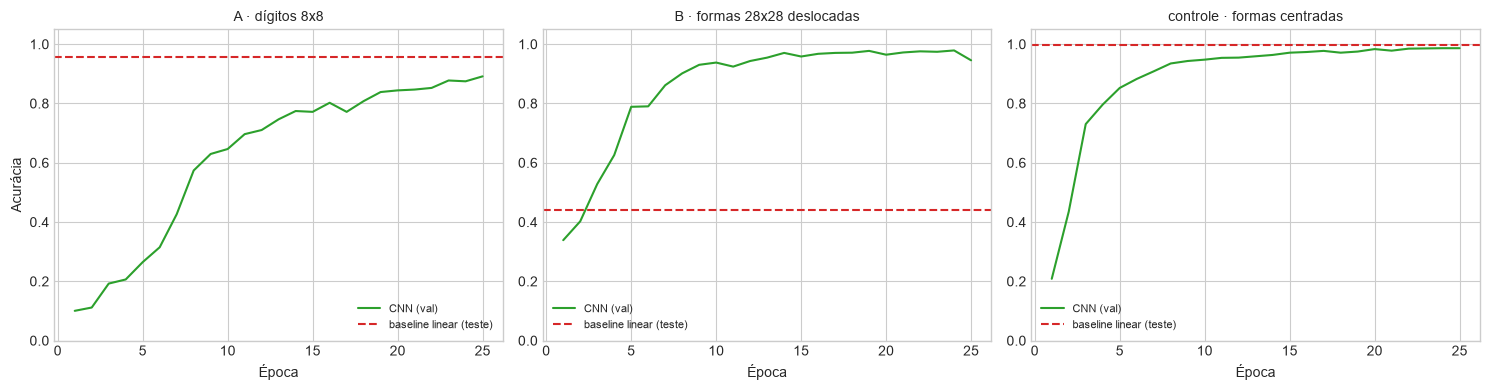

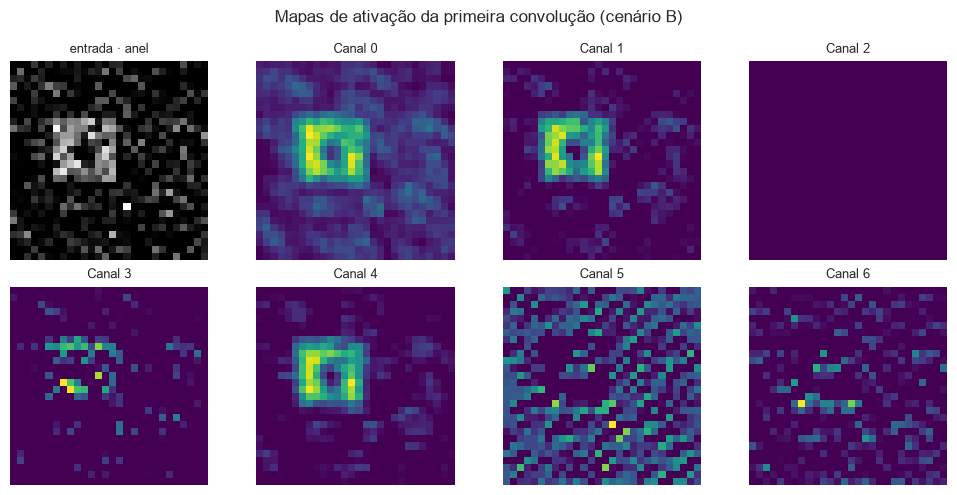

In [6]:
runs = {name: run_scenario(name, data) for name, data in scenarios.items()}

rows = []
for name, run in runs.items():
    rows.append({'cenario': name, 'modelo': 'Regressão logística',
                 'accuracy': run['baseline']['accuracy'], 'macro_f1': run['baseline']['macro_f1'],
                 'log_loss': run['baseline']['log_loss'], 'parametros_treinaveis': run['baseline_params']})
    rows.append({'cenario': name, 'modelo': 'CNN pequena',
                 'accuracy': run['cnn']['accuracy'], 'macro_f1': run['cnn']['macro_f1'],
                 'log_loss': run['cnn']['log_loss'], 'parametros_treinaveis': run['cnn_params']})
comparison_df = pd.DataFrame(rows)
print(comparison_df.round(4).to_string(index=False))

delta = pd.DataFrame([
    {'cenario': name,
     'acc_linear': run['baseline']['accuracy'],
     'acc_cnn': run['cnn']['accuracy'],
     'ganho_da_cnn_em_pp': 100 * (run['cnn']['accuracy'] - run['baseline']['accuracy'])}
    for name, run in runs.items()
])
print()
print(delta.round(2).to_string(index=False))
comparison_df

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, run) in zip(axes, runs.items()):
    ax.plot(run['history']['epoch'], run['history']['val_accuracy'], label='CNN (val)', color='tab:green')
    ax.axhline(run['baseline']['accuracy'], color='tab:red', linestyle='--', label='baseline linear (teste)')
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Época')
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8)
axes[0].set_ylabel('Acurácia')
plt.tight_layout()

scenario_b = 'B · formas 28x28 deslocadas'
sample_images = scenarios[scenario_b]['I_test'][:1, None, :, :]
sample = torch.tensor(sample_images, dtype=torch.float32).to(device)
with torch.no_grad():
    feature_maps = runs[scenario_b]['model'].features[:2](sample).cpu().numpy()[0]

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
axes.flat[0].imshow(sample_images[0, 0], cmap='gray')
axes.flat[0].set_title(f"entrada · {SHAPE_NAMES[scenarios[scenario_b]['y_test'][0]]}", fontsize=9)
for ax, fmap, idx in zip(axes.flat[1:], feature_maps[:7], range(7)):
    ax.imshow(fmap, cmap='viridis')
    ax.set_title(f'Canal {idx}', fontsize=9)
for ax in axes.flat:
    ax.axis('off')
plt.suptitle('Mapas de ativação da primeira convolução (cenário B)')
plt.tight_layout()

## Análise de erro, limitações e próximo experimento
A leitura correta não é "CNN é melhor" nem "CNN é pior", e sim **em que condições cada viés indutivo se paga**. A tabela de recall por classe no cenário B mostra onde o baseline linear desmorona: classes cuja assinatura é a mesma em qualquer posição (barras horizontais contra verticais, por exemplo) viram ruído para um modelo que só enxerga colunas independentes de pixels.

O cenário de controle fecha o argumento: como ele usa exatamente as mesmas formas, o único fator que muda é a translação. Se o baseline se recupera lá, então a derrota dele no cenário B não tem nada a ver com as formas serem difíceis — tem a ver com o modelo não ter o viés certo.

O próximo experimento natural é escalar para arquiteturas residuais, adicionar augmentation simples e verificar até onde a melhoria vem de profundidade versus transferência de conhecimento.

            classe  recall_baseline_B  recall_cnn_B  recall_baseline_controle  recall_cnn_controle
              cruz              0.432         1.000                     1.000                1.000
              anel              0.432         0.968                     1.000                0.973
        canto em L              0.677         1.000                     1.000                1.000
barras horizontais              0.441         0.959                     1.000                0.986
  barras verticais              0.414         0.986                     1.000                0.991
            xadrez              0.245         0.968                     0.991                0.945

Exemplos que o baseline linear erra e a CNN acerta: 8 mostrados (de 719 no total)


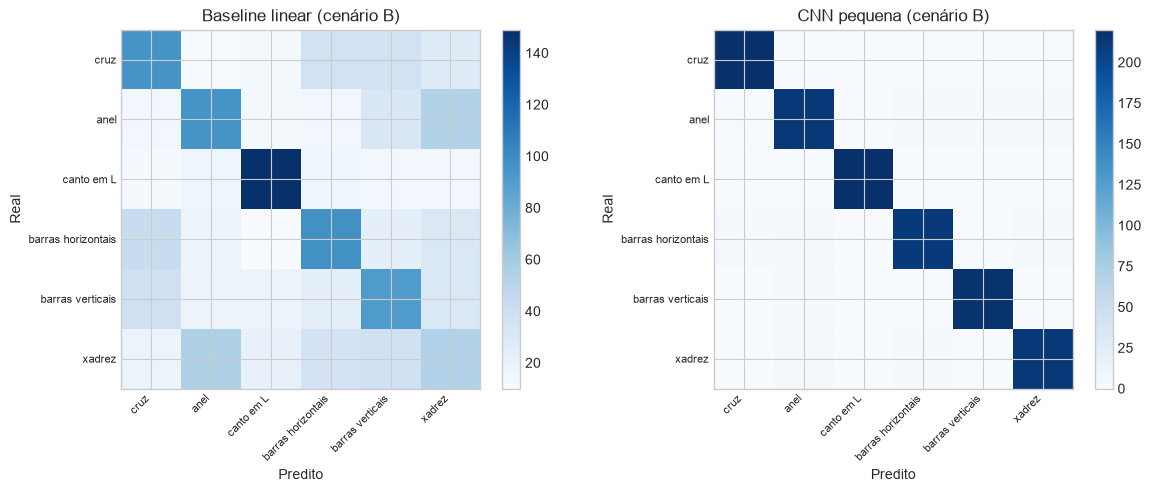

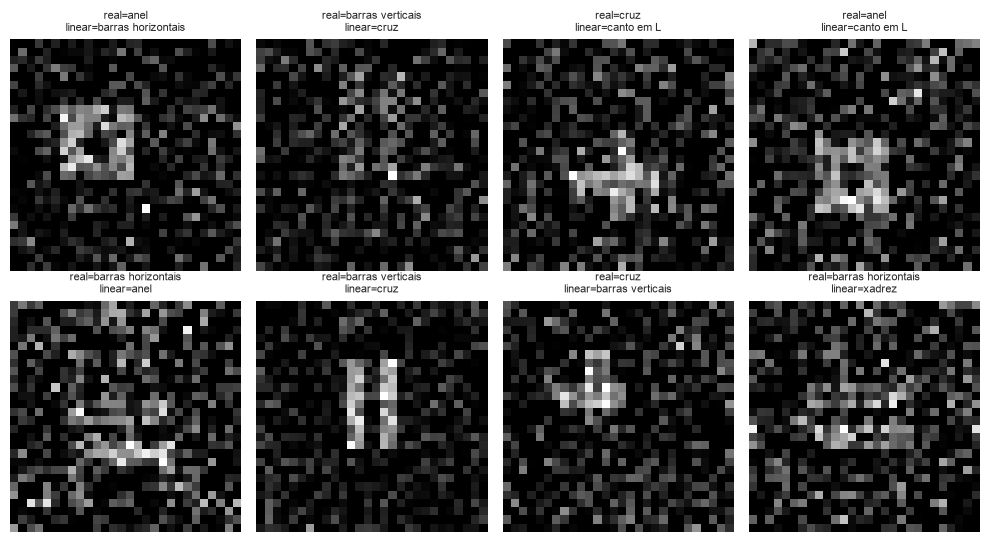

In [7]:
run_b = runs[scenario_b]
cm = confusion_matrix(run_b['cnn']['y_true'], run_b['cnn']['y_pred'])
cm_base = confusion_matrix(scenarios[scenario_b]['y_test'], run_b['baseline']['y_pred'])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, matrix, title in zip(axes, [cm_base, cm], ['Baseline linear (cenário B)', 'CNN pequena (cenário B)']):
    im = ax.imshow(matrix, cmap='Blues')
    ax.set_title(title)
    ax.set_xticks(range(len(SHAPE_NAMES)))
    ax.set_xticklabels(SHAPE_NAMES, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(len(SHAPE_NAMES)))
    ax.set_yticklabels(SHAPE_NAMES, fontsize=8)
    ax.set_xlabel('Predito')
    ax.set_ylabel('Real')
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()

recall_df = pd.DataFrame({
    'classe': SHAPE_NAMES,
    'recall_baseline_B': run_b['baseline']['per_class_recall'],
    'recall_cnn_B': run_b['cnn']['per_class_recall'],
    'recall_baseline_controle': runs['controle · formas centradas']['baseline']['per_class_recall'],
    'recall_cnn_controle': runs['controle · formas centradas']['cnn']['per_class_recall'],
})
print(recall_df.round(3).to_string(index=False))
recall_df

y_test_b = scenarios[scenario_b]['y_test']
images_b = scenarios[scenario_b]['I_test']
mis_idx = np.where(y_test_b != run_b['baseline']['y_pred'])[0]
cnn_ok = mis_idx[run_b['cnn']['y_pred'][mis_idx] == y_test_b[mis_idx]][:8]
print(f'\nExemplos que o baseline linear erra e a CNN acerta: {len(cnn_ok)} mostrados '
      f'(de {int((run_b["cnn"]["y_pred"][mis_idx] == y_test_b[mis_idx]).sum())} no total)')

fig, axes = plt.subplots(2, 4, figsize=(10, 5.5))
for ax, idx in zip(axes.flat, cnn_ok):
    ax.imshow(images_b[idx], cmap='gray')
    ax.set_title(f'real={SHAPE_NAMES[y_test_b[idx]]}\nlinear={SHAPE_NAMES[run_b["baseline"]["y_pred"][idx]]}',
                 fontsize=8)
    ax.axis('off')
for ax in axes.flat:
    ax.axis('off')
plt.tight_layout()

## Fechamento e próximos passos
O experimento separa claramente as situações. Na execução de referência (semente 42):

| cenário | baseline linear | CNN pequena | quem vence |
|---|---|---|---|
| A · dígitos 8×8 | **0.9556** (650 parâmetros) | 0.8611 (4.442) | **linear**, por 9,4 pp |
| B · formas 28×28 deslocadas | 0.4402 (4.710) | **0.9803** (4.310) | **CNN**, por 54,0 pp — e com **menos** parâmetros |
| controle · formas centradas | **0.9985** (4.710) | 0.9826 (4.310) | **linear**, por 1,6 pp |

Onde o padrão é **local e aparece em posições variáveis** (cenário B), a CNN entrega um salto de **54 pontos percentuais** de acurácia gastando **4.310 parâmetros contra 4.710 do baseline** — é o viés indutivo espacial pagando, e pagando barato. Onde a imagem é minúscula e já vem alinhada (cenário A), a invariância a translação vira desperdício: o baseline linear, que memoriza um molde de pixels por classe, vence com 6,8× menos parâmetros.

O **controle fecha o argumento causal**. São exatamente as mesmas seis formas, o mesmo ruído e o mesmo gerador; a única coisa removida foi o deslocamento. O baseline linear salta de **0.4402 para 0.9985** — ou seja, as formas nunca foram difíceis para ele. O que o derrubava era a translação, e é precisamente isso que o `AdaptiveMaxPool2d` da CNN neutraliza.

A moral para levar da aula é de desenho experimental: **um benchmark só responde à pergunta se o dataset contiver o sinal que a arquitetura foi feita para capturar**. Testar CNN apenas em `digits` 8×8 produziria a conclusão errada de que "convolução não ajuda".

Esse resultado abre a porta para a próxima aula, na qual o ganho deixa de ser apenas convolucional e passa a depender de profundidade residual, transferência de conhecimento e mecanismos de explicabilidade como Grad-CAM.